<a href="https://colab.research.google.com/github/adilkamal2478/Adil_Pandas_campusx/blob/main/Case_study1_Time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Pandas_CampusX/Case_study1/login.csv')
df

,1,466,2017-01-07 18:24:07,Unnamed: 3
0,2,466,2017-01-07 18:24:55,NaN
1,3,458,2017-01-07 18:25:18,NaN
2,4,458,2017-01-07 18:26:21,NaN
3,5,592,2017-01-07 19:09:59,NaN
4,6,393,2017-01-08 00:41:19,NaN
...,...,...,...,...
2997,2999,1307,2018-01-04 10:48:28,183.82.121.201
2998,3000,1230,2018-01-04 11:22:00,47.247.147.114
2999,3001,1307,2018-01-04 13:13:44,183.82.121.201
3000,3002,1307,2018-01-04 13:13:45,183.82.121.201


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3002 entries, 0 to 3001
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   1                    3002 non-null   int64 
 1   466                  3002 non-null   int64 
 2   2017-01-07 18:24:07  3002 non-null   object
 3   Unnamed: 3           2209 non-null   object
dtypes: int64(2), object(2)
memory usage: 93.9+ KB


In [5]:
# till now
# Timestamp
pd.Timestamp('6th jan 2023 8:10')
# DatetimeIndex -> df and series index
pd.DatetimeIndex([pd.Timestamp('6th jan 2023 8:10'),pd.Timestamp('7th jan 2023 8:10'),pd.Timestamp('8th jan 2023 8:10')])[0]
# date_range()
pd.date_range(start='2023-1-6',end='2023-1-31',freq='D')
# to_datetime()
s = pd.Series(['2023/1/6','2023/1/7','2023/1/11'])
pd.to_datetime(s).dt.day_name()

,0
0,Friday
1,Saturday
2,Wednesday


### Timedelta Object

Represents a duration, the difference between two dates or times.

In [6]:
# create using Timestamp objects
t1 = pd.Timestamp('6 jan 2023 8:20:14')
t2 = pd.Timestamp('26 jan 2023 10:0:0')

t1-t2
t2-t1

Timedelta('20 days 01:39:46')

In [7]:
# standalone creation
temp = pd.Timedelta(days=2,hours=10,minutes=35 , seconds=13)
temp

Timedelta('2 days 10:35:13')

In [8]:
# Arithmetic
pd.Timestamp('18 april 2004') + pd.Timedelta(days=2,hours=10,minutes=35 , seconds=13)

Timestamp('2004-04-20 10:35:13')

In [9]:
pd.date_range(start='2004/04/18' , end = '2004/05/18' , freq='D')   -   pd.Timedelta(days=2 , hours=10 , minutes=35 , seconds=14)

DatetimeIndex(['2004-04-15 13:24:46', '2004-04-16 13:24:46',
               '2004-04-17 13:24:46', '2004-04-18 13:24:46',
               '2004-04-19 13:24:46', '2004-04-20 13:24:46',
               '2004-04-21 13:24:46', '2004-04-22 13:24:46',
               '2004-04-23 13:24:46', '2004-04-24 13:24:46',
               '2004-04-25 13:24:46', '2004-04-26 13:24:46',
               '2004-04-27 13:24:46', '2004-04-28 13:24:46',
               '2004-04-29 13:24:46', '2004-04-30 13:24:46',
               '2004-05-01 13:24:46', '2004-05-02 13:24:46',
               '2004-05-03 13:24:46', '2004-05-04 13:24:46',
               '2004-05-05 13:24:46', '2004-05-06 13:24:46',
               '2004-05-07 13:24:46', '2004-05-08 13:24:46',
               '2004-05-09 13:24:46', '2004-05-10 13:24:46',
               '2004-05-11 13:24:46', '2004-05-12 13:24:46',
               '2004-05-13 13:24:46', '2004-05-14 13:24:46',
               '2004-05-15 13:24:46'],
              dtype='datetime64[ns]', freq='D'

In [10]:
# real life example
df = pd.read_csv('/content/drive/MyDrive/Pandas_CampusX/Case_study1/deliveries.csv')
df

,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98
...,...,...
496,6/24/91,2/2/96
497,9/9/91,3/30/98
498,11/16/90,4/27/98
499,6/3/93,6/13/93


In [11]:

df['total_date'] = pd.to_datetime(df['delivery_date']) - pd.to_datetime(df['order_date'])

/tmp/ipykernel_4823/2624981492.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['total_date'] = pd.to_datetime(df['delivery_date']) - pd.to_datetime(df['order_date'])
/tmp/ipykernel_4823/2624981492.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['total_date'] = pd.to_datetime(df['delivery_date']) - pd.to_datetime(df['order_date'])


In [12]:
df['total_date'].mean()

Timedelta('1217 days 22:53:53.532934128')

### Time series

A time series is a data set that tracks a sample over time. In particular, a time series allows one to see what factors influence certain variables from period to period. Time series analysis can be useful to see how a given asset, security, or economic variable changes over time.

Examples

- Financial Data (Company stocks)
- Natural Data (Rainfall measurement)
- Event Data (Covid)
- Medical Data (Heart rate monitoring)

Types of Operations done on Time Series

- Time Series Analysis
- Time Series Forecasting

In [22]:
google = pd.read_csv('/content/drive/MyDrive/Pandas_CampusX/Case_study1/google.csv')
google

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276
...,...,...,...,...,...,...,...
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600


In [23]:
google.info()
google['Date'] = pd.to_datetime(google['Date'])
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4471 non-null   object 
 1   Open       4471 non-null   float64
 2   High       4471 non-null   float64
 3   Low        4471 non-null   float64
 4   Close      4471 non-null   float64
 5   Adj Close  4471 non-null   float64
 6   Volume     4471 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 244.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4471 non-null   datetime64[ns]
 1   Open       4471 non-null   float64       
 2   High       4471 non-null   float64       
 3   Low        4471 non-null   float64       
 4   Close      4471 non-null   float64       
 5   Adj Close  4471 non-null   flo

In [24]:
google.set_index('Date' , inplace=True)
google.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276


In [25]:
# fetch a specific date
google.loc['2004-08-25']

,2004-08-25
Open,5.228403e+01
High,5.379835e+01
Low,5.174604e+01
Close,5.280209e+01
Adj Close,5.280209e+01
Volume,9.232276e+06


In [33]:
# partial indexing -> select a particular year/month
google.loc['2021-12']       # all dates of december 2021
google.loc['2021']       # all dates of 1 jan 2021 to 31 dec 2021


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-04,1757.540039,1760.650024,1707.849976,1728.239990,1728.239990,1901900
2021-01-05,1725.000000,1747.670044,1718.015015,1740.920044,1740.920044,1145300
2021-01-06,1702.630005,1748.000000,1699.000000,1735.290039,1735.290039,2602100
2021-01-07,1740.060059,1788.400024,1737.050049,1787.250000,1787.250000,2265000
2021-01-08,1787.979980,1809.839966,1773.535034,1807.209961,1807.209961,2050600
...,...,...,...,...,...,...
2021-12-27,2949.270020,2968.530029,2945.000000,2961.280029,2961.280029,662800
2021-12-28,2967.489990,2967.489990,2918.709961,2928.959961,2928.959961,931200
2021-12-29,2928.590088,2943.675049,2910.090088,2930.090088,2930.090088,851100


In [44]:
# create year month-name and day-name
google['month'] = google.index.month_name()
google


,Open,High,Low,Close,Adj Close,Volume,month
Date,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August
...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100,May
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800,May
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100,May


In [45]:
google['day'] = google.index.day_name()
google

,Open,High,Low,Close,Adj Close,Volume,month,day
Date,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday
...,...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100,May,Monday
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800,May,Tuesday
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100,May,Wednesday


In [46]:
google['quarter'] = google.index.quarter
google

,Open,High,Low,Close,Adj Close,Volume,month,day,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3
...,...,...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100,May,Monday,2
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800,May,Tuesday,2
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100,May,Wednesday,2


In [47]:
# slicing
google.loc['2021-01-15':'2022-01-15']

,Open,High,Low,Close,Adj Close,Volume,month,day,quarter
Date,,,,,,,,,
2021-01-15,1738.189941,1756.000000,1721.550049,1736.189941,1736.189941,1342200,January,Friday,1
2021-01-19,1752.250000,1809.275024,1741.459961,1790.859985,1790.859985,1734600,January,Tuesday,1
2021-01-20,1831.459961,1903.709961,1825.530029,1886.900024,1886.900024,2490300,January,Wednesday,1
2021-01-21,1898.000000,1934.859985,1887.109985,1891.250000,1891.250000,2063900,January,Thursday,1
2021-01-22,1895.680054,1910.949951,1881.760010,1901.050049,1901.050049,1272100,January,Friday,1
...,...,...,...,...,...,...,...,...,...
2022-01-10,2701.979980,2772.800049,2662.810059,2771.479980,2771.479980,1704800,January,Monday,1
2022-01-11,2763.610107,2806.590088,2736.270020,2800.350098,2800.350098,1175100,January,Tuesday,1
2022-01-12,2831.090088,2856.284912,2822.239990,2832.959961,2832.959961,1182100,January,Wednesday,1


In [59]:
# challenge -> fetch info for a particular date every year -> limitation of timedelta
# 6th jan of each year

pd.date_range(start = '2005-01-06' , end = '2022-01-06' , freq=pd.DateOffset(years=1))

google[google.index.isin(pd.date_range(start = '2005-01-06' , end = '2022-01-06' , freq=pd.DateOffset(years=1)))]


,Open,High,Low,Close,Adj Close,Volume,month,day,quarter
Date,,,,,,,,,
2005-01-06,97.175758,97.584229,93.509506,93.922951,93.922951,20852067,January,Thursday,1
2006-01-06,227.581970,234.371521,225.773743,231.960556,231.960556,35646914,January,Friday,1
2009-01-06,165.868286,169.763687,162.585587,166.406265,166.406265,12898566,January,Tuesday,1
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987226,January,Wednesday,1
2011-01-06,304.199799,308.060303,303.885956,305.604523,305.604523,4131026,January,Thursday,1
2012-01-06,328.344299,328.767700,323.681763,323.796326,323.796326,5405987,January,Friday,1
2014-01-06,554.426880,557.340942,551.154114,556.573853,556.573853,3551864,January,Monday,1
2015-01-06,513.589966,514.761719,499.678131,500.585632,500.585632,2899940,January,Tuesday,1
2016-01-06,730.000000,747.179993,728.919983,743.619995,743.619995,1947000,January,Wednesday,1


<Axes: xlabel='Date'>

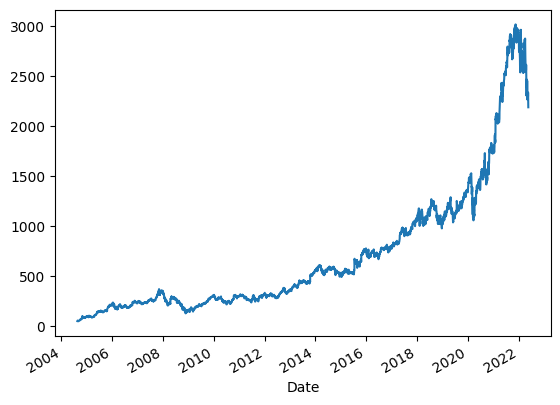

In [60]:
# viz a single col
google['Close'].plot()

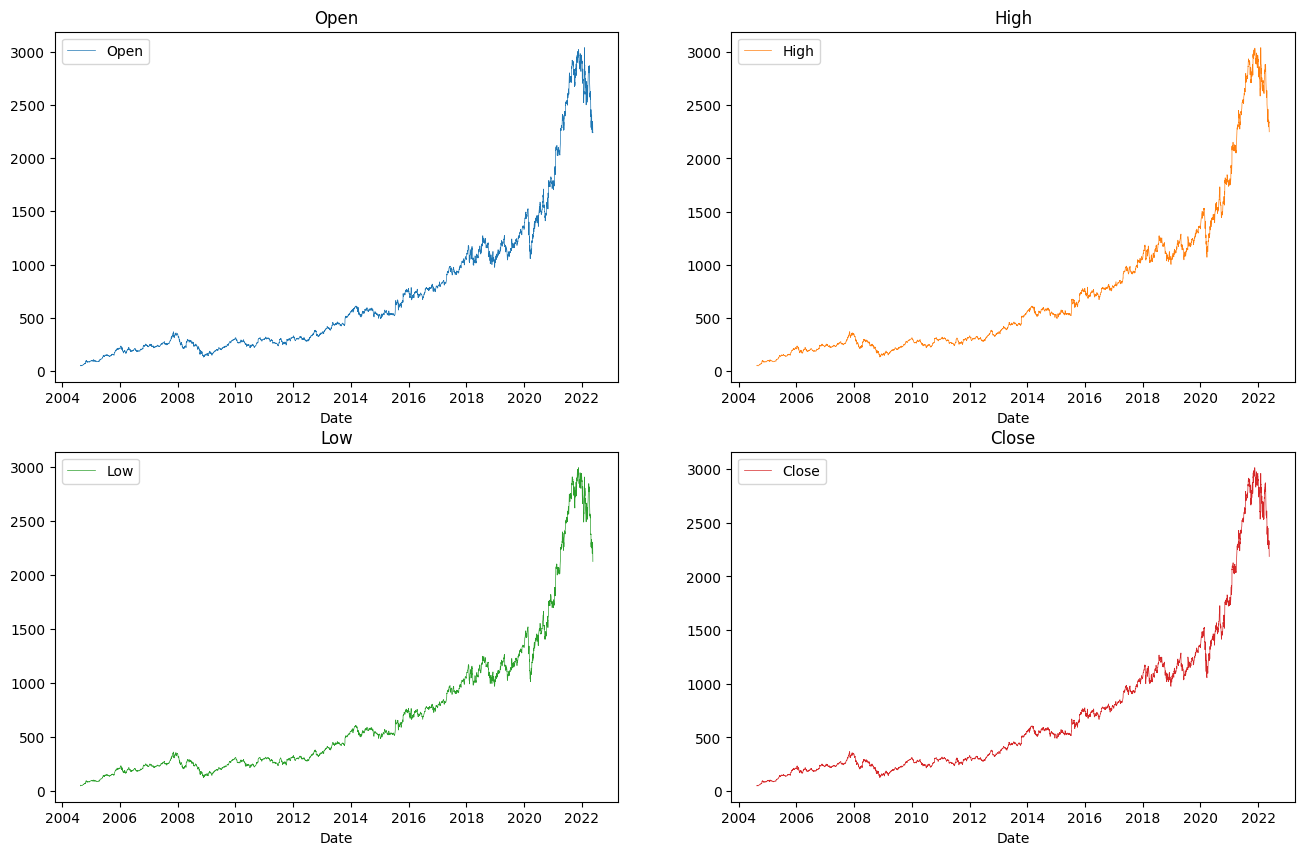

In [85]:
# viz all cols together

google
subset_google = google[['Open', 'High', 'Low', 'Close']]
ax = subset_google.plot(subplots=True,
                    layout=(2, 2),
                     sharex=False,
                     sharey=False,
                     linewidth=0.5,
                     fontsize=10,
                     legend=True,
                      figsize=(16,10),
                      title=['Open', 'High', 'Low', 'Close'])

<Axes: xlabel='Date'>

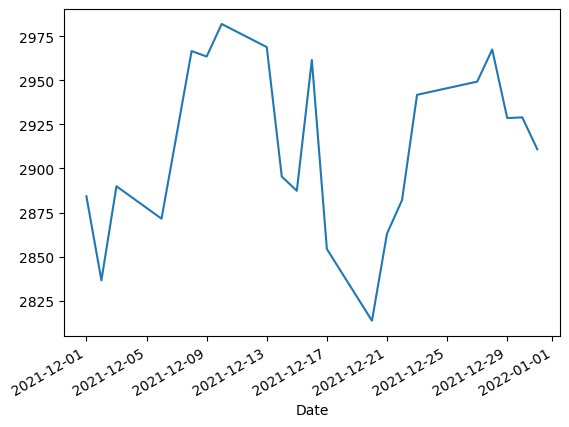

In [93]:
# plot for a particular year/month/week

# google.loc['2022']['Open'].plot()       # 2022
google.loc['2021-12']['Open'].plot()       # 2021 dec

<Axes: xlabel='month'>

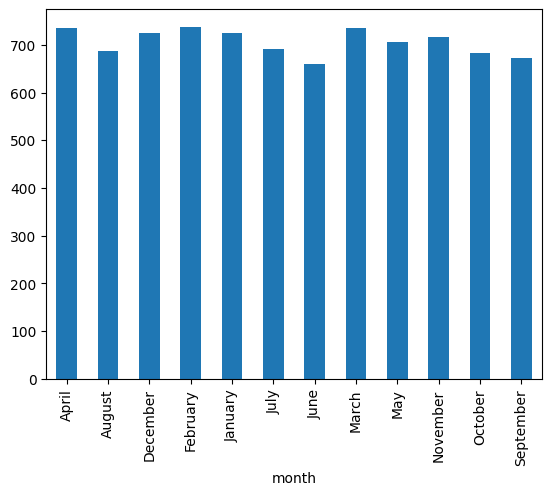

In [115]:
# monthly trend

google.groupby('month')['Close'].mean().plot(kind='bar')

In [98]:
# frequency
google.index

DatetimeIndex(['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24',
               '2004-08-25', '2004-08-26', '2004-08-27', '2004-08-30',
               '2004-08-31', '2004-09-01',
               ...
               '2022-05-09', '2022-05-10', '2022-05-11', '2022-05-12',
               '2022-05-13', '2022-05-16', '2022-05-17', '2022-05-18',
               '2022-05-19', '2022-05-20'],
              dtype='datetime64[ns]', name='Date', length=4471, freq=None)

In [102]:
# asfreq
google = google.asfreq('B')
google

,Open,High,Low,Close,Adj Close,Volume,month,day,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897.0,August,Monday,3.0
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808.0,August,Tuesday,3.0
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276.0,August,Wednesday,3.0
...,...,...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100.0,May,Monday,2.0
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800.0,May,Tuesday,2.0
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100.0,May,Wednesday,2.0


In [110]:
google.asfreq('ME')         # all month end datas
google.asfreq('Y')         # all year end datas
google.asfreq('Q')         # all quarter end datas

google.asfreq('H')          # each hour data
google.asfreq('6H')          # each 6 hour data



/tmp/ipykernel_4823/2437430778.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  google.asfreq('Y')         # all year end datas
/tmp/ipykernel_4823/2437430778.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  google.asfreq('Q')         # all quarter end datas
/tmp/ipykernel_4823/2437430778.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google.asfreq('H')          # each hour data
/tmp/ipykernel_4823/2437430778.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google.asfreq('6H')          # each 6 hour data


,Open,High,Low,Close,Adj Close,Volume,month,day,quarter
Date,,,,,,,,,
2004-08-19 00:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-19 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-19 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-19 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-20 00:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
...,...,...,...,...,...,...,...,...,...
2022-05-19 00:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600.0,May,Thursday,2.0
2022-05-19 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-19 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
# u can fill those NaN data

google.asfreq('6H' , method = 'bfill')          # last value will be filled to upper NaN
google.asfreq('6H' , method = 'ffill')          # upper value will be filled to lower NaN


/tmp/ipykernel_4823/3133617775.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google.asfreq('6H' , method = 'bfill')          # last value will be filled to upper NaN
/tmp/ipykernel_4823/3133617775.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google.asfreq('6H' , method = 'ffill')          # last value will be filled to upper NaN


,Open,High,Low,Close,Adj Close,Volume,month,day,quarter
Date,,,,,,,,,
2004-08-19 00:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-19 06:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-19 12:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-19 18:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-20 00:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
...,...,...,...,...,...,...,...,...,...
2022-05-19 00:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600.0,May,Thursday,2.0
2022-05-19 06:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600.0,May,Thursday,2.0
2022-05-19 12:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600.0,May,Thursday,2.0


### Resampling

Resampling involves changing the frequency of your time series observations.

Two types of resampling are:

**Upsampling**: Where you increase the frequency of the samples, such as from minutes to seconds.<br>
**Downsampling**: Where you decrease the frequency of the samples, such as from days to months.

/tmp/ipykernel_4823/468006921.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  google['Close'].resample('Q').mean().plot()
/tmp/ipykernel_4823/468006921.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  google['Close'].resample('Q').mean().plot()


<Axes: xlabel='Date'>

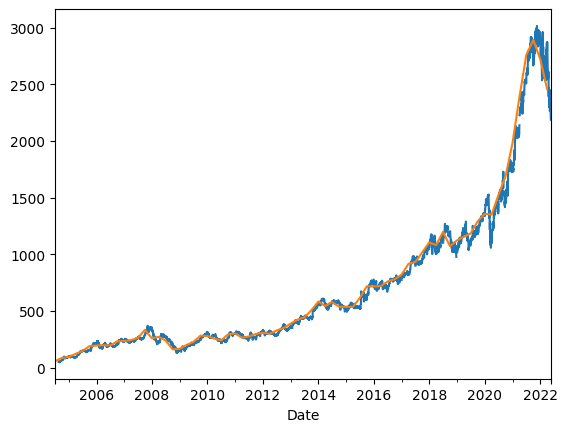

In [125]:
# Downsampling
# NOTE - in 99% cases we do downsampling , rarely use upsampling

google['Close'].plot()
google['Close'].resample('Q').mean().plot()

/tmp/ipykernel_4823/2226105503.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google['Close'].resample('12H').interpolate(method='spline',order=2).plot()


<Axes: xlabel='Date'>

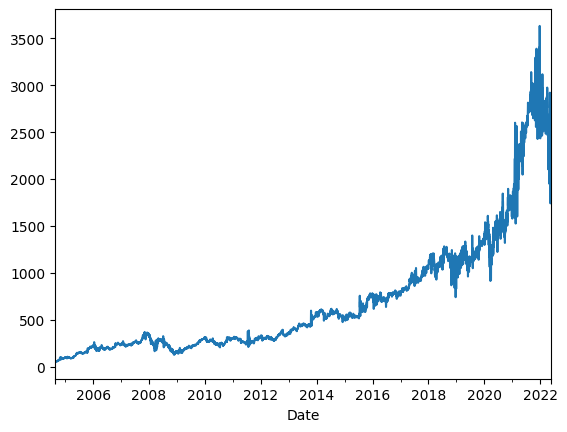

In [126]:
# Upsampling
google['Close'].resample('12H').interpolate(method='spline',order=2).plot()

### Rolling Window(Smoothing)
Time series data in original format can be quite volatile, especially on smaller aggregation levels. The concept of rolling, or moving averages is a useful technique for smoothing time series data.

<Axes: xlabel='Date'>

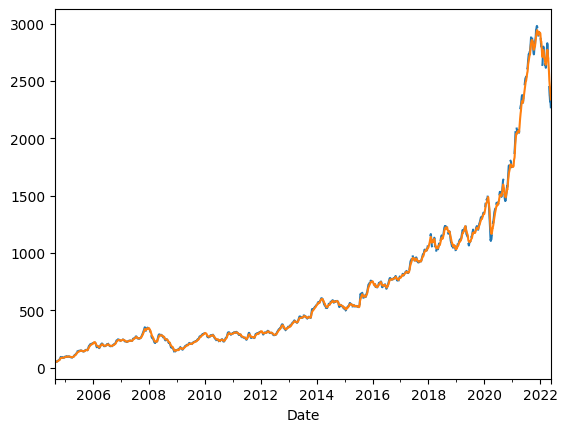

In [132]:
# Rolling window

google['Close'].rolling(10).mean().plot()
google['Close'].ewm(10).mean().plot()

### Shifting

The shift() function is Pandas is used to, well, shift the entire series up or down by the desired number of periods.

In [136]:
google['Open'].shift(1)
google['Open'].shift(2)
google['Open'].shift(-2)

,Open
Date,
2004-08-19,55.168217
2004-08-20,55.412300
2004-08-23,52.284027
2004-08-24,52.279045
2004-08-25,53.848164
...,...
2022-05-16,2304.750000
2022-05-17,2236.820068
2022-05-18,2241.709961


In [140]:
# shift example
df = pd.read_csv('/content/drive/MyDrive/Pandas_CampusX/Case_study1/login.csv' , header=None)
df = df[[1,2]]
df.rename(columns={1:'user_id' , 2:'login_time'} , inplace=True)
df.head()

,user_id,login_time
0,466,2017-01-07 18:24:07
1,466,2017-01-07 18:24:55
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
4,592,2017-01-07 19:09:59


In [141]:
df['user_id'].value_counts()

,count
user_id,
413,222
458,208
492,162
882,140
592,122
...,...
1275,1
1276,1
639,1


In [147]:
# Average return time the a perticular person (413)

user_df = df[df['user_id'] == 413]
user_df

,user_id,login_time
11,413,2017-01-09 12:29:25
12,413,2017-01-09 12:40:39
14,413,2017-01-09 14:08:04
33,413,2017-01-10 14:36:23
35,413,2017-01-10 15:22:45
...,...,...
2958,413,2017-12-29 18:20:32
2963,413,2017-12-30 13:41:21
2974,413,2018-01-01 15:16:25
2982,413,2018-01-02 18:15:45


In [149]:
user_df['login_time'] = pd.to_datetime(user_df['login_time'])
user_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222 entries, 11 to 2997
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     222 non-null    int64         
 1   login_time  222 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 13.3 KB


/tmp/ipykernel_4823/897488481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['login_time'] = pd.to_datetime(user_df['login_time'])


In [154]:
user_df['shifted'] = user_df['login_time'].shift(1)
user_df

/tmp/ipykernel_4823/1354605783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['shifted'] = user_df['login_time'].shift(1)


,user_id,login_time,shifted
11,413,2017-01-09 12:29:25,NaT
12,413,2017-01-09 12:40:39,2017-01-09 12:29:25
14,413,2017-01-09 14:08:04,2017-01-09 12:40:39
33,413,2017-01-10 14:36:23,2017-01-09 14:08:04
35,413,2017-01-10 15:22:45,2017-01-10 14:36:23
...,...,...,...
2958,413,2017-12-29 18:20:32,2017-12-29 18:19:48
2963,413,2017-12-30 13:41:21,2017-12-29 18:20:32
2974,413,2018-01-01 15:16:25,2017-12-30 13:41:21
2982,413,2018-01-02 18:15:45,2018-01-01 15:16:25


In [158]:
user_df['difference'] = user_df['login_time'] - user_df['shifted']
user_df
print(user_df['difference'].mean())

1 days 15:05:13.384615384


/tmp/ipykernel_4823/4185562671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['difference'] = user_df['login_time'] - user_df['shifted']
